In [26]:
import pandas as pd 
import networkx as nx 
import numpy as np 

import matplotlib.pyplot as plt
import ndlib.models.ModelConfig as mc

from ndlib.models.CompositeModel import CompositeModel

from ndlib.models.compartments.NodeStochastic import NodeStochastic
from ndlib.models.compartments.EdgeStochastic import EdgeStochastic

In [27]:
edgelist = pd.read_csv("twitch_edgelist_10K.csv")

nodes = pd.read_csv("twitch_nodes_10k_final.csv")

In [ ]:
# Creazione grafo
G_full = nx.from_pandas_edgelist(edgelist, source='Source', target='Target', create_using=nx.Graph())

#attribuzione dell'attributo follower ai nodi
node_attributes = nodes.set_index('ID').to_dict(orient='index')
nx.set_node_attributes(G_full, node_attributes)

# Estrazione della Componente Connessa Principale per la simulazione
components = sorted(nx.connected_components(G_full), key=len, reverse=True)
G_core = G_full.subgraph(components[0]).copy()

print(f"Nodi totali in G_core: {G_core.number_of_nodes()}")

Nodi totali in G_core: 10355


In [ ]:
# Visualizziamo le statistiche descrittive generali
print("--- STATISTICHE FOLLOWERS ---")
print(nodes['Total_Followers'].describe().apply(lambda x: f"{x:,.0f}"))

# Calcolo dinamico dei percentili
# 99° percentile per definire l'élite, 70° percentile per definire la base
soglia_grandi = nodes['Total_Followers'].quantile(0.99)
soglia_piccoli = nodes['Total_Followers'].quantile(0.70)

print("\n--- SOGLIE SELEZIONATE PER IL MODELLO ---")
print(f"Top Streamer (99° percentile): >= {soglia_grandi:.0f} follower")
print(f"Piccoli Creator (70° percentile): <= {soglia_piccoli:.0f} follower")

--- STATISTICHE FOLLOWERS ---
count       10,356
mean        15,172
std        121,016
min              0
25%            134
50%            457
75%          2,230
max      8,962,279
Name: Total_Followers, dtype: object

--- SOGLIE SELEZIONATE PER IL MODELLO ---
Top Streamer (99° percentile): >= 306073 follower
Piccoli Creator (70° percentile): <= 1499 follower


In [30]:
soglia_grandi = 300000
soglia_piccoli = 1500

Numero di Top Streamer infettati inizialmente: 108



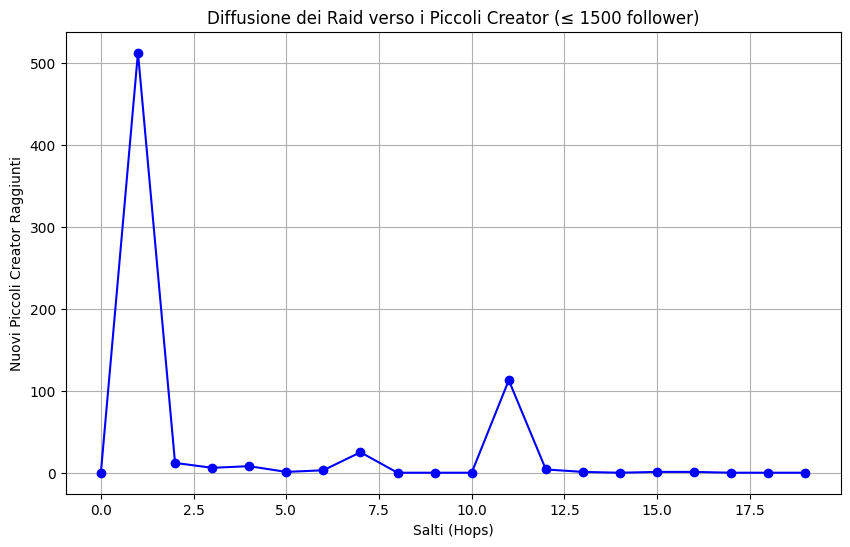

In [ ]:

raid_model = CompositeModel(G_core)

# Definizione degli stati
raid_model.add_status("Susceptible")
raid_model.add_status("Infected")

# Regola di diffuione, 15% di probabilità
condition = EdgeStochastic(triggering_status="Infected", probability=0.15)
raid_model.add_rule("Susceptible", "Infected", condition)

# Configurazione pazienti zero
config = mc.Configuration()
top_streamers = [n for n, attr in G_core.nodes(data=True) if attr.get('Total_Followers', 0) >= soglia_grandi]
print(f"Numero di Top Streamer infettati inizialmente: {len(top_streamers)}\n")

config.add_model_initial_configuration("Infected", top_streamers)
raid_model.set_initial_status(config)

numero_salti = 20
iterations = raid_model.iteration_bunch(numero_salti)

small_creators_raided_per_hop = []

for step in iterations:
    small_raided_count = 0
    for node_id, new_status in step['status'].items():
        # Verifichiamo se il nodo ha cambiato stato e se rientra nella soglia_piccoli
        if new_status == 1 and G_core.nodes[node_id].get('Total_Followers', 0) <= soglia_piccoli:
            small_raided_count += 1
    small_creators_raided_per_hop.append(small_raided_count)

# Plot dei risultati
plt.figure(figsize=(10, 6))
plt.plot(range(numero_salti), small_creators_raided_per_hop, marker='o', color='b')
plt.title(f"Diffusione dei Raid verso i Piccoli Creator (\u2264 {soglia_piccoli:.0f} follower)")
plt.xlabel("Salti (Hops)")
plt.ylabel("Nuovi Piccoli Creator Raggiunti")
plt.grid(True)
plt.show()

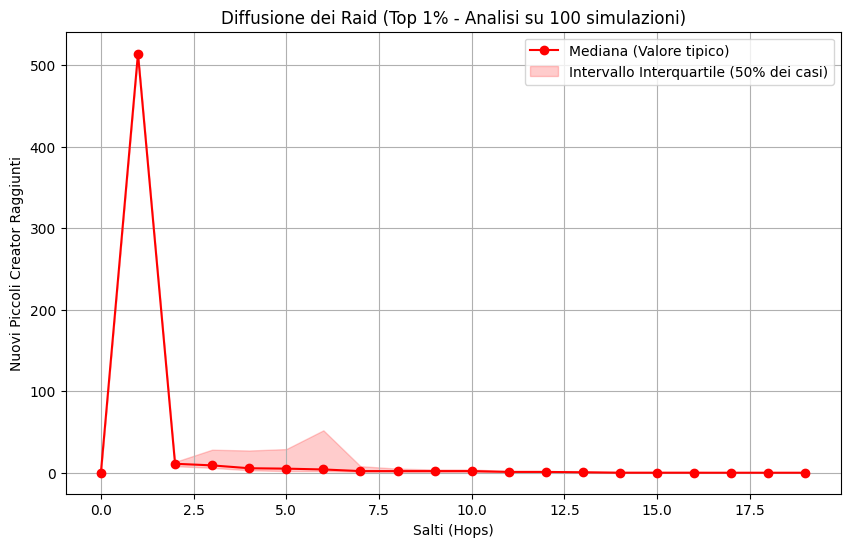

In [ ]:
num_simulazioni = 100
numero_salti = 20


# Matrice per i risultati
tutti_i_risultati = np.zeros((num_simulazioni, numero_salti))

for i in range(num_simulazioni):
    raid_model = CompositeModel(G_core)
    raid_model.add_status("Susceptible")
    raid_model.add_status("Infected")
    
    # Regola di diffusione
    condition = EdgeStochastic(triggering_status="Infected", probability=0.15)
    raid_model.add_rule("Susceptible", "Infected", condition)
    
    # Pazienti Zero
    config = mc.Configuration()
    top_streamers = [n for n, attr in G_core.nodes(data=True) if attr.get('Total_Followers', 0) >= soglia_grandi]
    config.add_model_initial_configuration("Infected", top_streamers)
    raid_model.set_initial_status(config)
    
    # Loop iterazioni
    iterations = raid_model.iteration_bunch(numero_salti)
    for step in iterations:
        hop = step['iteration']
        count = sum(1 for n, s in step['status'].items() 
                    if s == 1 and G_core.nodes[n].get('Total_Followers', 0) <= soglia_piccoli)
        tutti_i_risultati[i, hop] = count

# --- CALCOLO STATISTICO ---
mediana = np.median(tutti_i_risultati, axis=0)
p25 = np.percentile(tutti_i_risultati, 25, axis=0)
p75 = np.percentile(tutti_i_risultati, 75, axis=0)

# --- PLOTTING ---
plt.figure(figsize=(10, 6))
plt.plot(range(numero_salti), mediana, label="Mediana (Valore tipico)", color='red', marker='o')
plt.fill_between(range(numero_salti), p25, p75, color='red', alpha=0.2, label="Intervallo Interquartile (50% dei casi)")

plt.title(f"Diffusione dei Raid (Top 1% - Analisi su {num_simulazioni} simulazioni)")
plt.xlabel("Salti (Hops)")
plt.ylabel("Nuovi Piccoli Creator Raggiunti")
plt.legend()
plt.grid(True)
plt.show()

In [33]:
print("--- STATISTICHE FOLLOWERS ---")
print(nodes['Total_Followers'].describe().apply(lambda x: f"{x:,.0f}"))

# Calcolo dinamico dei percentili
# 97° percentile per definire l'élite, 70° percentile per definire la base
soglia_grandi = nodes['Total_Followers'].quantile(0.97)
soglia_piccoli = nodes['Total_Followers'].quantile(0.70)

print("\n--- SOGLIE SELEZIONATE PER IL MODELLO ---")
print(f"Top Streamer (97° percentile): >= {soglia_grandi:.0f} follower")
print(f"Piccoli Creator (70° percentile): <= {soglia_piccoli:.0f} follower")

--- STATISTICHE FOLLOWERS ---
count       10,356
mean        15,172
std        121,016
min              0
25%            134
50%            457
75%          2,230
max      8,962,279
Name: Total_Followers, dtype: object

--- SOGLIE SELEZIONATE PER IL MODELLO ---
Top Streamer (97° percentile): >= 100682 follower
Piccoli Creator (70° percentile): <= 1499 follower


In [34]:
soglia_grandi = 100000
soglia_piccoli = 1500

Numero di Top Streamer infettati inizialmente: 313



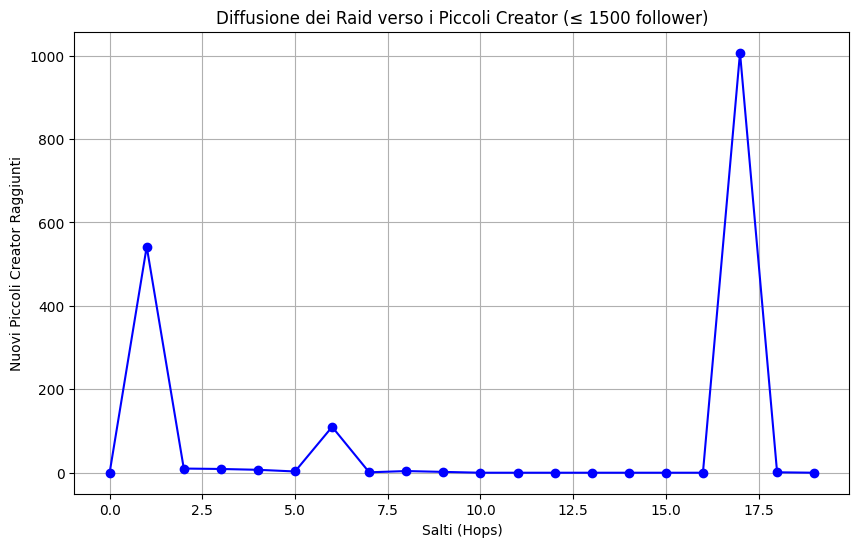

In [ ]:

raid_model = CompositeModel(G_core)

# Definizione degli stati
raid_model.add_status("Susceptible")
raid_model.add_status("Infected")

# Regola di probabilità: 15%
condition = EdgeStochastic(triggering_status="Infected", probability=0.15)
raid_model.add_rule("Susceptible", "Infected", condition)

# Configurazione pazienti zero
config = mc.Configuration()
top_streamers = [n for n, attr in G_core.nodes(data=True) if attr.get('Total_Followers', 0) >= soglia_grandi]
print(f"Numero di Top Streamer infettati inizialmente: {len(top_streamers)}\n")

config.add_model_initial_configuration("Infected", top_streamers)
raid_model.set_initial_status(config)

# Esecuzione simulazione
numero_salti = 20
iterations = raid_model.iteration_bunch(numero_salti)

small_creators_raided_per_hop = []

for step in iterations:
    small_raided_count = 0
    for node_id, new_status in step['status'].items():
        # Verifichiamo se il nodo ha cambiato stato e se rientra nella soglia_piccoli
        if new_status == 1 and G_core.nodes[node_id].get('Total_Followers', 0) <= soglia_piccoli:
            small_raided_count += 1
    small_creators_raided_per_hop.append(small_raided_count)

# Plot dei risultati
plt.figure(figsize=(10, 6))
plt.plot(range(numero_salti), small_creators_raided_per_hop, marker='o', color='b')
plt.title(f"Diffusione dei Raid verso i Piccoli Creator (\u2264 {soglia_piccoli:.0f} follower)")
plt.xlabel("Salti (Hops)")
plt.ylabel("Nuovi Piccoli Creator Raggiunti")
plt.grid(True)
plt.show()

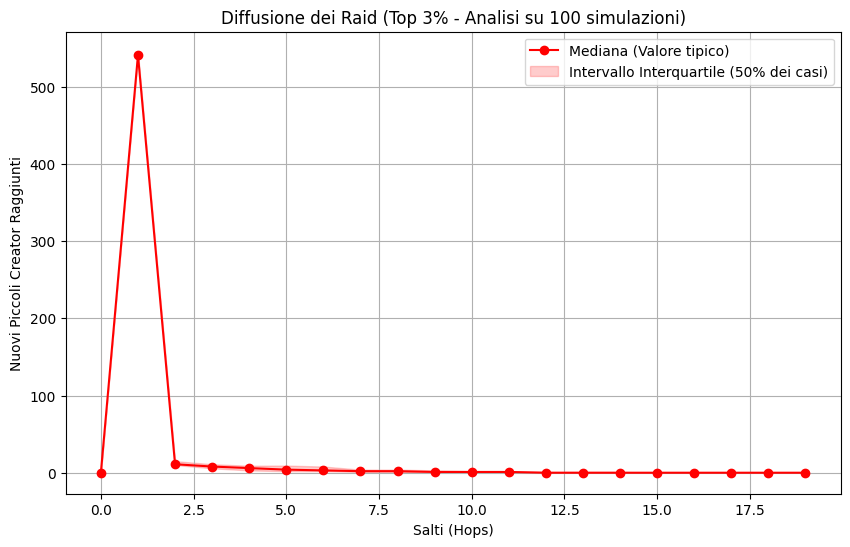

In [ ]:
num_simulazioni = 100
numero_salti = 20


# Matrice per i risultati
tutti_i_risultati = np.zeros((num_simulazioni, numero_salti))

for i in range(num_simulazioni):
    raid_model = CompositeModel(G_core)
    raid_model.add_status("Susceptible")
    raid_model.add_status("Infected")
    
    # Regola di diffusione
    condition = EdgeStochastic(triggering_status="Infected", probability=0.15)
    raid_model.add_rule("Susceptible", "Infected", condition)
    
    # Pazienti Zero
    config = mc.Configuration()
    top_streamers = [n for n, attr in G_core.nodes(data=True) if attr.get('Total_Followers', 0) >= soglia_grandi]
    config.add_model_initial_configuration("Infected", top_streamers)
    raid_model.set_initial_status(config)
    
    # Loop iterazioni
    iterations = raid_model.iteration_bunch(numero_salti)
    for step in iterations:
        hop = step['iteration']
        count = sum(1 for n, s in step['status'].items() 
                    if s == 1 and G_core.nodes[n].get('Total_Followers', 0) <= soglia_piccoli)
        tutti_i_risultati[i, hop] = count

# --- CALCOLO STATISTICO ---
mediana = np.median(tutti_i_risultati, axis=0)
p25 = np.percentile(tutti_i_risultati, 25, axis=0)
p75 = np.percentile(tutti_i_risultati, 75, axis=0)

plt.figure(figsize=(10, 6))
plt.plot(range(numero_salti), mediana, label="Mediana (Valore tipico)", color='red', marker='o')
plt.fill_between(range(numero_salti), p25, p75, color='red', alpha=0.2, label="Intervallo Interquartile (50% dei casi)")

plt.title(f"Diffusione dei Raid (Top 3% - Analisi su {num_simulazioni} simulazioni)")
plt.xlabel("Salti (Hops)")
plt.ylabel("Nuovi Piccoli Creator Raggiunti")
plt.legend()
plt.grid(True)
plt.show()

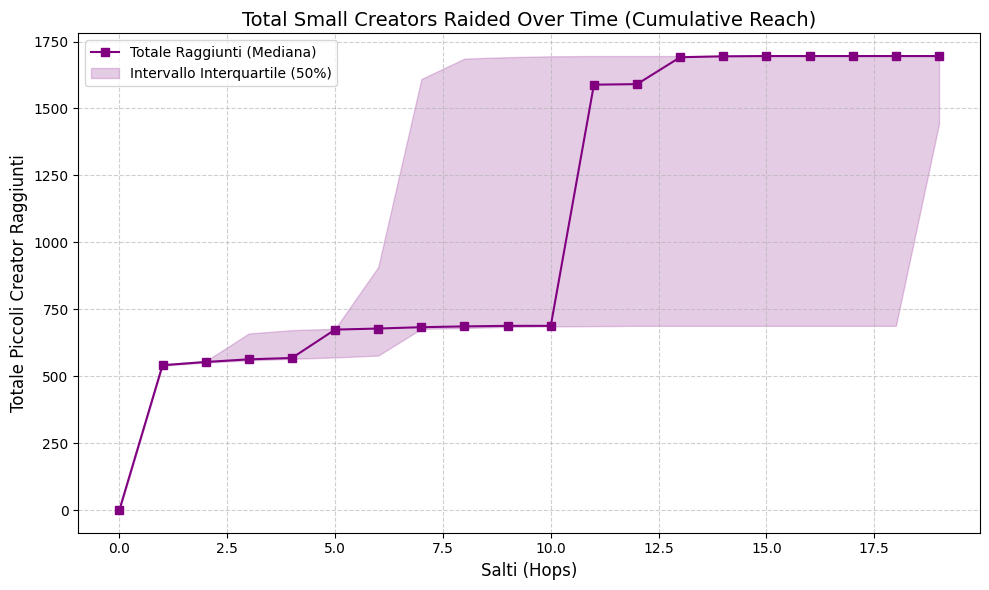

In [40]:
# Calcoliamo la somma cumulativa per ogni simulazione sull'asse degli hops
risultati_cumulativi = np.cumsum(tutti_i_risultati, axis=1)

# Calcolo Mediana e Percentili sulla cumulativa
mediana_cum = np.median(risultati_cumulativi, axis=0)
p25_cum = np.percentile(risultati_cumulativi, 25, axis=0)
p75_cum = np.percentile(risultati_cumulativi, 75, axis=0)

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(range(numero_salti), mediana_cum, label="Totale Raggiunti (Mediana)", color='purple', marker='s')
plt.fill_between(range(numero_salti), p25_cum, p75_cum, color='purple', alpha=0.2, label="Intervallo Interquartile (50%)")

plt.title("Total Small Creators Raided Over Time (Cumulative Reach)", fontsize=14)
plt.xlabel("Salti (Hops)", fontsize=12)
plt.ylabel("Totale Piccoli Creator Raggiunti", fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

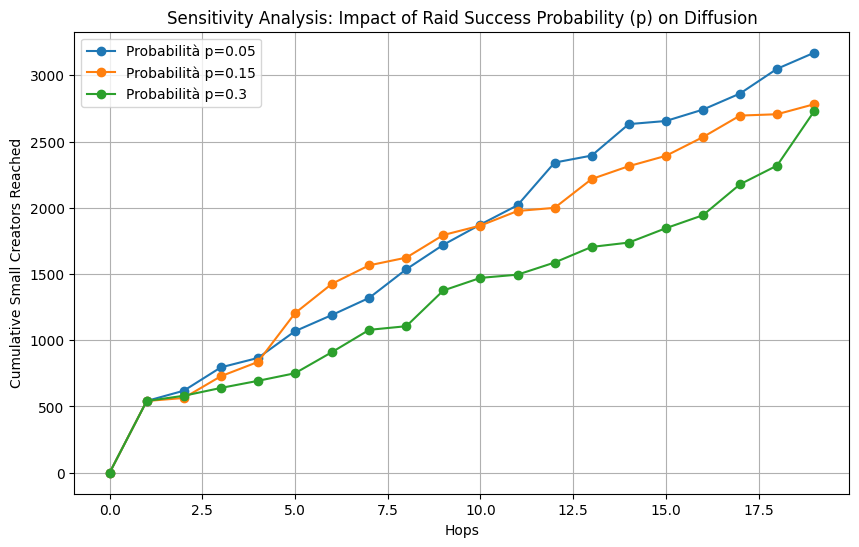

In [ ]:
probabilita_test = [0.05, 0.15, 0.30]
numero_simulazioni = 100
numero_salti = 20
soglia_grandi = 100000 

plt.figure(figsize=(10, 6))

for p in probabilita_test:
    risultati_p = np.zeros((numero_simulazioni, numero_salti))
    
    for i in range(numero_simulazioni):
        model = CompositeModel(G_core)
        model.add_status("Susceptible")
        model.add_status("Infected")
        
        condition = EdgeStochastic(triggering_status="Infected", probability=p)
        model.add_rule("Susceptible", "Infected", condition)
        
        top_streamers = [n for n, attr in G_core.nodes(data=True) if attr.get('Total_Followers', 0) >= soglia_grandi]
        config = mc.Configuration()
        config.add_model_initial_configuration("Infected", top_streamers)
        model.set_initial_status(config)
        
        iterations = model.iteration_bunch(numero_salti)
        for step in iterations:
            hop = step['iteration']
            count = sum(1 for n, s in step['status'].items() 
                        if s == 1 and G_core.nodes[n].get('Total_Followers', 0) <= 1500)
            risultati_p[i, hop] = count
            
    # Plotting della mediana per ogni p
    mediana_p = np.median(risultati_p, axis=1) # Usiamo la cumulativa per vedere l'impatto totale
    plt.plot(range(numero_salti), np.cumsum(risultati_p, axis=1).mean(axis=0), 
             label=f"Probabilità p={p}", marker='o')

plt.title("Sensitivity Analysis: Impact of Raid Success Probability (p) on Diffusion")
plt.xlabel("Hops")
plt.ylabel("Cumulative Small Creators Reached")
plt.legend()
plt.grid(True)
plt.savefig("sensitivity_analysis.png", dpi=300)
plt.show()